In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import globals as gl
from Pcm import find_model, calc_normalized_likelihood_in_parcel, get_likelihood_in_parcel
import PcmPy as pcm
import pickle
from scipy.stats import ttest_1samp, pearsonr
from matplotlib.patches import ConnectionPatch, Rectangle
from matplotlib import colormaps as cm
from Plot import add_significant_patches_to_ml_rois, add_lineplot_to_boxplot, set_spines_and_ticks_width, add_noise_ceiling, save_figure_incremental

plt.style.use('default')

Base directory found: /cifs/diedrichsen/data/SensoriMotorPrediction/
Base directory: /cifs/diedrichsen/data/SensoriMotorPrediction/


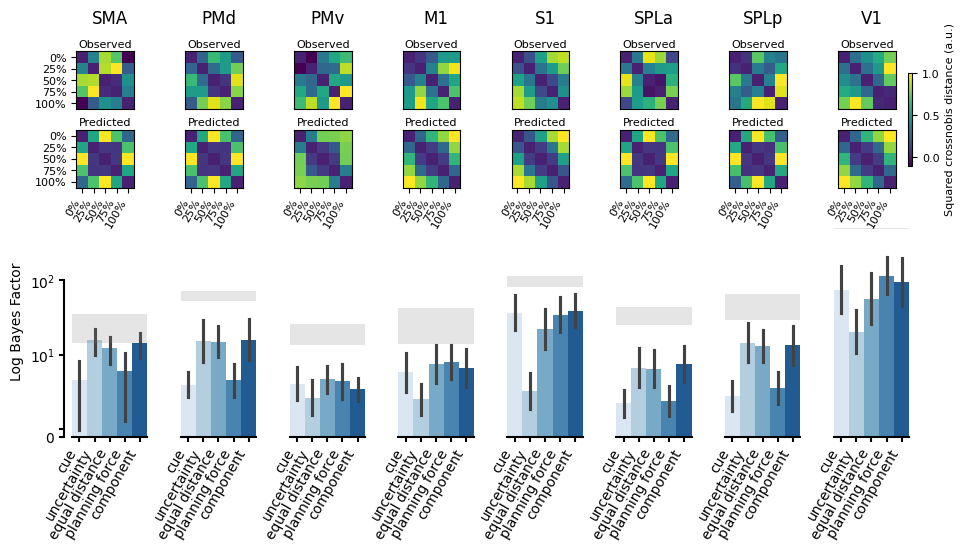

In [2]:
rois = ['SMA', 'PMd', 'PMv', 'M1', 'S1', 'SPLa', 'SPLp', 'V1']
glm = 12
Hem = 'L'
experiment = 'smp2'

Mc, idxc = find_model(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'M.plan.glm{glm}.pkl'), 'component')

vmin, vmax = -.1, 1

fig, axs = plt.subplots(1, len(rois), figsize=(11, 3), sharex=True, sharey=True)

LL = pd.DataFrame()
for r, roi in enumerate(rois):

    T_cv = pd.read_pickle(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'T_cv.plan.glm{glm}.{Hem}.{roi}.pkl'))
    T_gr = pd.read_pickle(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'T_gr.plan.glm{glm}.{Hem}.{roi}.pkl'))

    plt.sca(axs[r])
    ax = pcm.model_plot(T_cv.likelihood,
                    null_model = 'null',
                    noise_ceiling= 'ceil',
                    upper_ceiling = T_gr.likelihood['ceil'],
                    width=1,
                    palette='Blues',
                    errorbar='se')
    ax.set_title(roi, pad=20)
    ax.set_xlabel('')
    ax.set_yscale('symlog', linscale=.1, linthresh=1)
    ax.spines[['bottom',]].set_bounds(-.5, 4.5)
    ax.spines[['left',]].set_bounds(0, 10**2)
    ax.set_ylim(0, 10**3 - 0.0001)
    ax.set_yticks([0, 10, 100])
    ax.set_xlim(-1, 5)
    ax.set_xticks(ax.get_xticks())
    ax.set_xticklabels(ax.get_xticklabels(), rotation=60, ha='right')

    G_obs = np.load(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'G_obs.plan.glm{glm}.{Hem}.{roi}.npy')).mean(axis=0)
    D_obs = pcm.G_to_dist(G_obs / np.trace(G_obs))

    f = open(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'theta_cv.plan.glm{glm}.{Hem}.{roi}.pkl'), "rb")
    theta = pickle.load(f)
    theta_c = theta[idxc][:Mc.n_param]

    Dc = []
    for i in range(theta_c.shape[1]):
        G_hat_c, _ = Mc.predict(theta_c[:, i])
        Dc.append(pcm.G_to_dist(G_hat_c / np.trace(G_hat_c)))

    insetx = .05
    insety = (1.08, 1.42)
    insetw = .8
    inseth = .25
    cbarc = (insety[0] + insety[1] + inseth) / 2
    cbarx = .9
    cbarw = 0.4

    # Create first inset (upper)
    inset1 = ax.inset_axes([insetx, insety[1], insetw, inseth], transform=ax.transAxes)  # [x0, y0, width, height]
    cax = inset1.imshow(D_obs, vmin=vmin, vmax=vmax)  # Replace with your plotting code for the first inset
    inset1.set_xticks([])
    inset1.set_yticks([])
    inset1.set_title('Observed', fontsize=8, pad=3)
    if r==0:
        inset1.set_yticks(np.arange(5))
        inset1.set_yticklabels(list(gl.regressor_mapping.keys())[:5], fontsize=8)


    # Create second inset (just below the first)
    inset2 = ax.inset_axes([insetx, insety[0], insetw, inseth], transform=ax.transAxes)
    inset2.imshow(np.array(Dc).mean(axis=0), vmin=vmin, vmax=vmax)
    inset2.set_title('Predicted', fontsize=8, pad=3)
    inset2.set_xticks(np.arange(5))
    inset2.set_xticklabels(list(gl.regressor_mapping.keys())[:5], fontsize=8, rotation=60, ha='right')
    inset2.set_yticks([])
    if r==0:
        inset2.set_yticks(np.arange(5))
        inset2.set_yticklabels(list(gl.regressor_mapping.keys())[:5], fontsize=8,)

    # Add colorbar
    if r == len(rois) - 1:
        cbar_ax = ax.inset_axes([cbarx, cbarc-cbarw/2, 0.05, cbarw], transform=ax.transAxes)  # [left, bottom, width, height] in figure coordinates
        cbar = fig.colorbar(cax, cax=cbar_ax)
        cbar.ax.tick_params(labelsize=8)
        cbar.set_label('Squared crossnobis distance (a.u.)', fontsize=8)

    if r == 0:
        ax.spines[['top', 'right',]].set_visible(False)
        set_spines_and_ticks_width(ax, spine_width=1.5,spine_sides=('left', 'bottom',), tick_width=1.5,axes=('x', 'y'),which='both')
    else:
        ax.spines[['top', 'right','left']].set_visible(False)
        set_spines_and_ticks_width(ax, tick_width=0, axes='y')
        set_spines_and_ticks_width(ax, spine_width=1.5,spine_sides=('bottom',), tick_width=1.5,axes='x',which='both')

# fig.tight_layout()
# save_figure_incremental(fig, 'ml_neural_plan')
plt.show()

SMA, correlation1=PearsonRResult(statistic=np.float64(-0.08002004170016504), pvalue=np.float64(0.8150816765210345))
SMA, correlation2=PearsonRResult(statistic=np.float64(-0.14851952422859144), pvalue=np.float64(0.6629679383038292))
SMA, correlation3=PearsonRResult(statistic=np.float64(0.29060127142472303), pvalue=np.float64(0.38598305759802237))
PMd, correlation1=PearsonRResult(statistic=np.float64(0.5089478102948457), pvalue=np.float64(0.10985386355306818))
PMd, correlation2=PearsonRResult(statistic=np.float64(0.159445885870217), pvalue=np.float64(0.6395790863450113))
PMd, correlation3=PearsonRResult(statistic=np.float64(0.5403012699601616), pvalue=np.float64(0.08618591164719575))
PMv, correlation1=PearsonRResult(statistic=np.float64(0.6296419232958289), pvalue=np.float64(0.037894925670711926))
PMv, correlation2=PearsonRResult(statistic=np.float64(0.217378085989852), pvalue=np.float64(0.5208268599791416))
PMv, correlation3=PearsonRResult(statistic=np.float64(0.42861677494049405), pval

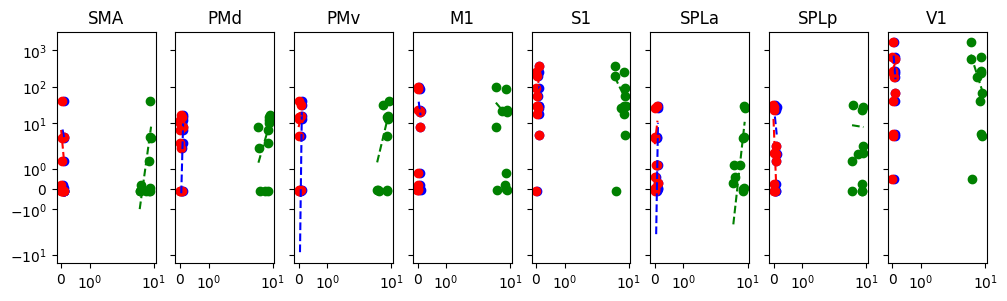

In [3]:
snS = [102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112]
experiment = 'smp2'
glm = 12

df = pd.DataFrame()
diff1, diff2, diff3 = np.zeros(len(snS)), np.zeros(len(snS)), np.zeros(len(snS))
for s, sn in enumerate(snS):
    df_tmp = pd.read_csv(os.path.join(gl.baseDir, experiment, gl.behavDir, f'subj{sn}', f'{experiment}_{sn}_force_single_trial.tsv'), sep='\t')
    dat = pd.read_csv(os.path.join(gl.baseDir, experiment, gl.behavDir, f'subj{sn}', f'{experiment}_{sn}.dat'), sep='\t')
    df_tmp['sn'] = sn
    df = pd.concat([df,df_tmp ])
    diff1[s] = (df[df['cue'] == 39]['index0'].mean() - df[df['cue'] == 93]['index0'].mean() +
            df[df['cue'] == 93]['ring0'].mean() - df[df['cue'] == 39]['ring0'].mean()) / 2
    diff3[s] = (df[df['stimFinger'] == 91999]['index1'].mean() - df[df['stimFinger'] == 99919]['index1'].mean() +
            df[df['stimFinger'] == 99919]['ring1'].mean() - df[df['stimFinger'] == 91999]['ring1'].mean()) / 2
    diff2[s] = dat['forceDiff'].mean()

fig, axs = plt.subplots(1, len(rois), sharex=True, sharey=True, figsize=(12, 3))

for r, roi in enumerate(rois):

    LL_cue = pd.read_pickle(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'T_cv.plan.glm{glm}.{Hem}.{roi}.pkl'))['likelihood']['cue'] - pd.read_pickle(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'T_cv.plan.glm{glm}.{Hem}.{roi}.pkl'))['likelihood']['null']

    # Regression for diff1
    coef1 = np.polyfit(diff1, LL_cue, 1)  # [slope, intercept]
    x1 = np.array([np.min(diff1), np.max(diff1)])
    y1 = coef1[0] * x1 + coef1[1]
    axs[r].plot(x1, y1, color='b', linestyle='--')

    # Regression for diff2
    coef2 = np.polyfit(diff2, LL_cue, 1)
    x2 = np.array([np.min(diff2), np.max(diff2)])
    y2 = coef2[0] * x2 + coef2[1]
    axs[r].plot(x2, y2, color='r', linestyle='--')

    # Regression for diff2
    coef3 = np.polyfit(diff3, LL_cue, 1)
    x3 = np.array([np.min(diff3), np.max(diff3)])
    y3 = coef3[0] * x3 + coef3[1]
    axs[r].plot(x3, y3, color='g', linestyle='--')

    print(f'{roi}, correlation1={pearsonr(diff1, LL_cue)}')
    print(f'{roi}, correlation2={pearsonr(diff2, LL_cue)}')
    print(f'{roi}, correlation3={pearsonr(diff3, LL_cue)}')

    axs[r].scatter(diff1, LL_cue, color='b')
    axs[r].scatter(diff2, LL_cue, color='r')
    axs[r].scatter(diff3, LL_cue, color='g')
    axs[r].set_yscale('symlog')
    axs[r].set_xscale('symlog')
    axs[r].set_title(roi)

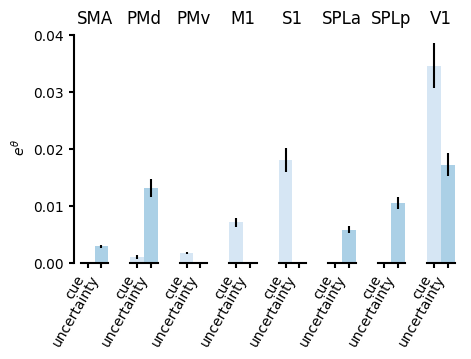

In [4]:
rois = ['SMA', 'PMd', 'PMv', 'M1', 'S1', 'SPLa', 'SPLp', 'V1']
glm = 14
Hem = 'L'
experiment = 'smp2'

M, idx = find_model(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'M.plan.glm{glm}.pkl'), 'component')
n_param = M.n_param
components = ['cue','uncertainty']

fig, axs = plt.subplots(1, len(rois), sharex=True, sharey=True, figsize=(5, 3),)

colors = sns.color_palette("Blues", n_colors=5)[:2]

for r, roi in enumerate(rois):

    f = open(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'theta_cv.plan.glm{glm}.{Hem}.{roi}.pkl'), "rb")
    theta = np.exp(pickle.load(f)[idx][:n_param])

    theta_avg = theta.mean(axis=1)
    theta_err = theta.std(axis=1) / np.sqrt(theta.shape[1])

    axs[r].bar(components, theta_avg, width=1, facecolor=colors, yerr=theta_err,)
    axs[r].set_xticks(axs[r].get_xticks())
    axs[r].set_xticklabels(axs[r].get_xticklabels(), rotation=60, ha='right')

    axs[r].set_title(roi)

    axs[r].spines[['bottom',]].set_bounds(-.5, 1.5)
    axs[r].spines[['left',]].set_bounds(0, .04)
    axs[r].set_xlim(-1, 2)

    if r == 0:
        axs[r].set_ylabel(r'$e^{\theta}$')
        axs[r].spines[['top', 'right',]].set_visible(False)
        set_spines_and_ticks_width(axs[r], spine_width=1.5,spine_sides=('left', 'bottom',), tick_width=1.5,axes=('x', 'y'),which='both')
    else:
        axs[r].spines[['top', 'right','left']].set_visible(False)
        set_spines_and_ticks_width(axs[r], tick_width=0, axes='y')
        set_spines_and_ticks_width(axs[r], spine_width=1.5,spine_sides=('bottom',), tick_width=1.5,axes='x',which='both')

plt.show()

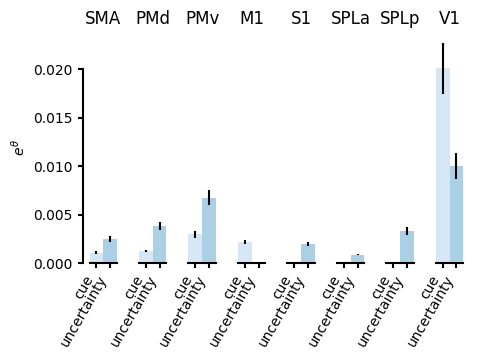

In [5]:
rois = ['SMA', 'PMd', 'PMv', 'M1', 'S1', 'SPLa', 'SPLp', 'V1']
glm = 14
Hem = 'R'
experiment = 'smp2'

M, idx = find_model(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'M.plan.glm{glm}.pkl'), 'component')
n_param = M.n_param
components = ['cue','uncertainty']

fig, axs = plt.subplots(1, len(rois), sharex=True, sharey=True, figsize=(5, 3),)

colors = sns.color_palette("Blues", n_colors=5)[:2]

for r, roi in enumerate(rois):

    f = open(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'theta_cv.plan.glm{glm}.{Hem}.{roi}.pkl'), "rb")
    theta = np.exp(pickle.load(f)[idx][:n_param])

    theta_avg = theta.mean(axis=1)
    theta_err = theta.std(axis=1) / np.sqrt(theta.shape[1])

    axs[r].bar(components, theta_avg, width=1, facecolor=colors, yerr=theta_err,)
    axs[r].set_xticks(axs[r].get_xticks())
    axs[r].set_xticklabels(axs[r].get_xticklabels(), rotation=60, ha='right')

    axs[r].set_title(roi)

    axs[r].spines[['bottom',]].set_bounds(-.5, 1.5)
    axs[r].spines[['left',]].set_bounds(0, .02)
    axs[r].set_xlim(-1, 2)

    if r == 0:
        axs[r].set_ylabel(r'$e^{\theta}$')
        axs[r].spines[['top', 'right',]].set_visible(False)
        set_spines_and_ticks_width(axs[r], spine_width=1.5,spine_sides=('left', 'bottom',), tick_width=1.5,axes=('x', 'y'),which='both')
    else:
        axs[r].spines[['top', 'right','left']].set_visible(False)
        set_spines_and_ticks_width(axs[r], tick_width=0, axes='y')
        set_spines_and_ticks_width(axs[r], spine_width=1.5,spine_sides=('bottom',), tick_width=1.5,axes='x',which='both')

plt.show()

Figure saved to: /cifs/diedrichsen/data/SensoriMotorPrediction/figures/ml_neural_exec_12.svg


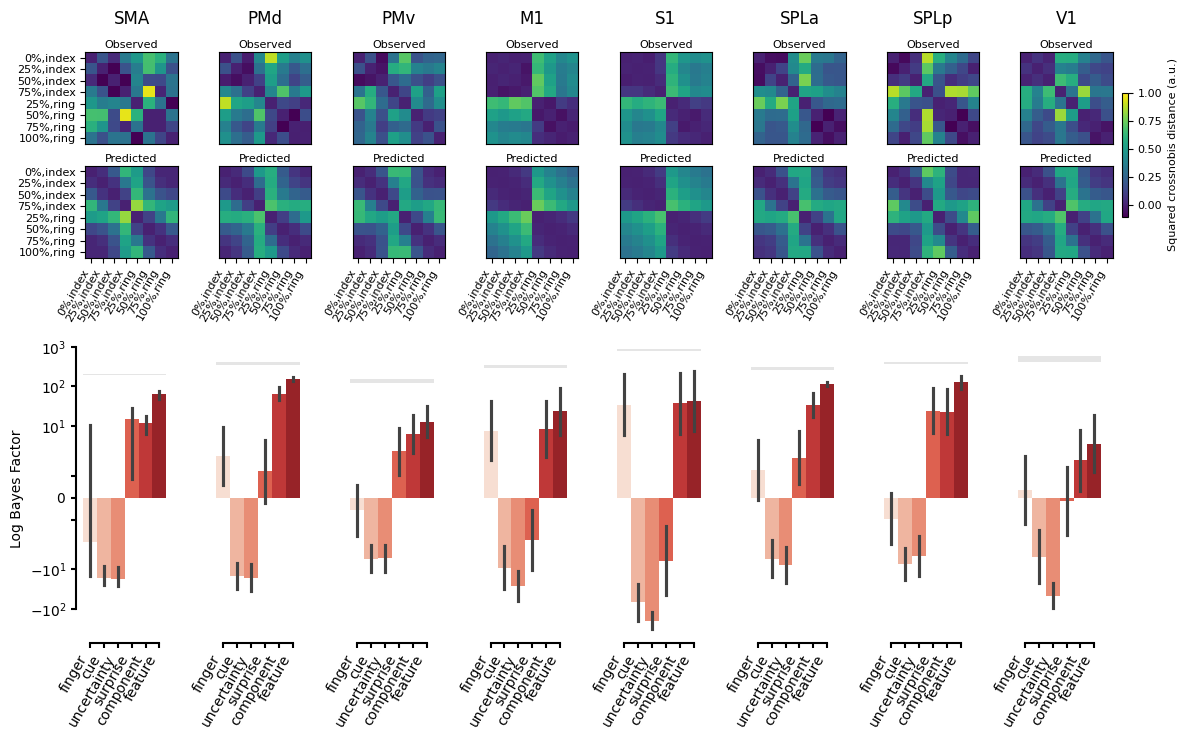

In [6]:
rois = ['SMA', 'PMd', 'PMv', 'M1', 'S1', 'SPLa', 'SPLp', 'V1']
glm = 12
Hem = 'L'
experiment = 'smp2'

Mf, idxf = find_model(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'M.exec.glm{glm}.pkl'), 'feature')

fig, axs = plt.subplots(1, len(rois), figsize=(13.5, 4), sharex=True, sharey=True)

colors = sns.color_palette("Reds", n_colors=5)

LL = pd.DataFrame()
for r, roi in enumerate(rois):

    T_cv = pd.read_pickle(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'T_cv.exec.glm{glm}.{Hem}.{roi}.pkl'))
    T_gr = pd.read_pickle(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'T_gr.exec.glm{glm}.{Hem}.{roi}.pkl'))

    plt.sca(axs[r])
    ax = pcm.model_plot(T_cv.likelihood,
                    null_model = 'null',
                    noise_ceiling= 'ceil',
                    upper_ceiling = T_gr.likelihood['ceil'],
                    width=1,
                    palette='Reds',
                    errorbar='se',)
    ax.set_title(roi, pad=20)
    ax.set_xlabel('')
    ax.set_yscale('symlog')
    ax.spines[['bottom',]].set_bounds(0, 5)
    ax.spines[['left',]].set_bounds(-10**2, 10**3)
    ax.set_yticks([ -100, -10, 0, 10, 100, 1000])
    ax.set_xlim(-1, 7)
    ax.set_xticks(ax.get_xticks())
    ax.set_xticklabels(ax.get_xticklabels(), rotation=60, ha='right')

    G_obs = np.load(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'G_obs.exec.glm{glm}.{Hem}.{roi}.npy')).mean(axis=0)
    D_obs = pcm.G_to_dist(G_obs / np.trace(G_obs))

    f = open(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'theta_cv.exec.glm{glm}.{Hem}.{roi}.pkl'), "rb")
    theta = pickle.load(f)
    theta_f = theta[idxf][:Mf.n_param]

    Df = []
    for i in range(theta_f.shape[1]):
        G_hat_f, _ = Mf.predict(theta_f[:, i])
        Df.append(pcm.G_to_dist(G_hat_f / np.trace(G_hat_f)))

    insetx = .05
    insety = (1.25, 1.62)
    insetw = .9
    inseth = .3
    cbarc = (insety[0] + insety[1] + inseth) / 2
    cbarx = 1
    cbarw = 0.4

    # Create first inset (upper)
    inset1 = ax.inset_axes([insetx, insety[1], insetw, inseth], transform=ax.transAxes)  # [x0, y0, width, height]
    cax = inset1.imshow(D_obs, vmin=vmin, vmax=vmax)  # Replace with your plotting code for the first inset
    inset1.set_xticks([])
    inset1.set_yticks([])
    inset1.set_title('Observed', fontsize=8, pad=3)
    if r==0:
        inset1.set_yticks(np.arange(8))
        inset1.set_yticklabels(list(gl.regressor_mapping.keys())[5:13], fontsize=8)

    # Create second inset (just below the first)
    inset2 = ax.inset_axes([insetx, insety[0], insetw, inseth], transform=ax.transAxes)
    inset2.imshow(np.array(Df).mean(axis=0), vmin=vmin, vmax=vmax)
    inset2.set_title('Predicted', fontsize=8, pad=3)
    inset2.set_xticks(np.arange(8))
    inset2.set_xticklabels(list(gl.regressor_mapping.keys())[5:13], fontsize=8, rotation=60, ha='right')
    inset2.set_yticks([])
    if r==0:
        inset2.set_yticks(np.arange(8))
        inset2.set_yticklabels(list(gl.regressor_mapping.keys())[5:13], fontsize=8,)

    # Add colorbar
    if r == len(rois) - 1:
        cbar_ax = ax.inset_axes([cbarx, cbarc-cbarw/2, 0.05, cbarw], transform=ax.transAxes)  # [left, bottom, width, height] in figure coordinates
        cbar = fig.colorbar(cax, cax=cbar_ax)
        cbar.ax.tick_params(labelsize=8)
        cbar.set_label('Squared crossnobis distance (a.u.)', fontsize=8)

    if r == 0:
        ax.spines[['top', 'right',]].set_visible(False)
        set_spines_and_ticks_width(ax, spine_width=1.5,spine_sides=('left', 'bottom',), tick_width=1.5,axes=('x', 'y'),which='both')
    else:
        ax.spines[['top', 'right','left']].set_visible(False)
        set_spines_and_ticks_width(ax, tick_width=0, axes='y')
        set_spines_and_ticks_width(ax, spine_width=1.5,spine_sides=('bottom',), tick_width=1.5,axes='x',which='both')

save_figure_incremental(fig, 'ml_neural_exec')

plt.show()

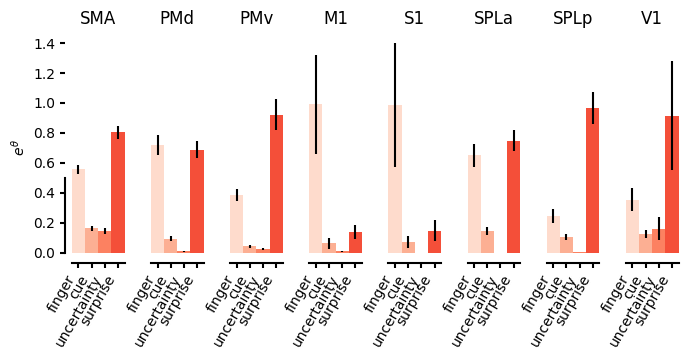

In [7]:
rois = ['SMA', 'PMd', 'PMv', 'M1', 'S1', 'SPLa', 'SPLp', 'V1']
glm = 12
Hem = 'L'
experiment = 'smp2'

M, idx = find_model(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'M.exec.glm{glm}.pkl'), 'component')
n_param = M.n_param
components = ['finger', 'cue','uncertainty', 'surprise']

fig, axs = plt.subplots(1, len(rois), sharex=True, sharey=True, figsize=(8, 3),)

colors = sns.color_palette("Reds", n_colors=6)[:4]

for r, roi in enumerate(rois):

    f = open(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'theta_in.exec.glm{glm}.{Hem}.{roi}.pkl'), "rb")
    theta = np.exp(pickle.load(f)[idx][:n_param])

    theta_avg = theta.mean(axis=1)
    theta_err = theta.std(axis=1) / np.sqrt(theta.shape[1])

    axs[r].bar(components, theta_avg / np.linalg.norm(theta_avg), width=1, facecolor=colors, yerr=theta_err,)
    axs[r].set_xticks(axs[r].get_xticks())
    axs[r].set_xticklabels(axs[r].get_xticklabels(), rotation=60, ha='right')

    axs[r].set_title(roi)

    axs[r].spines[['bottom',]].set_bounds(-.5, 3.5)
    axs[r].spines[['left',]].set_bounds(0, .5)
    axs[r].set_xlim(-1, 4)

    if r == 0:
        axs[r].set_ylabel(r'$e^{\theta}$')
        axs[r].spines[['top', 'right',]].set_visible(False)
        set_spines_and_ticks_width(axs[r], spine_width=1.5,spine_sides=('left', 'bottom',), tick_width=1.5,axes=('x', 'y'),which='both')
    else:
        axs[r].spines[['top', 'right','left']].set_visible(False)
        set_spines_and_ticks_width(axs[r], tick_width=0, axes='y')
        set_spines_and_ticks_width(axs[r], spine_width=1.5,spine_sides=('bottom',), tick_width=1.5,axes='x',which='both')

plt.show()

Figure saved to: /cifs/diedrichsen/data/SensoriMotorPrediction/figures/feature_coeff_11.svg


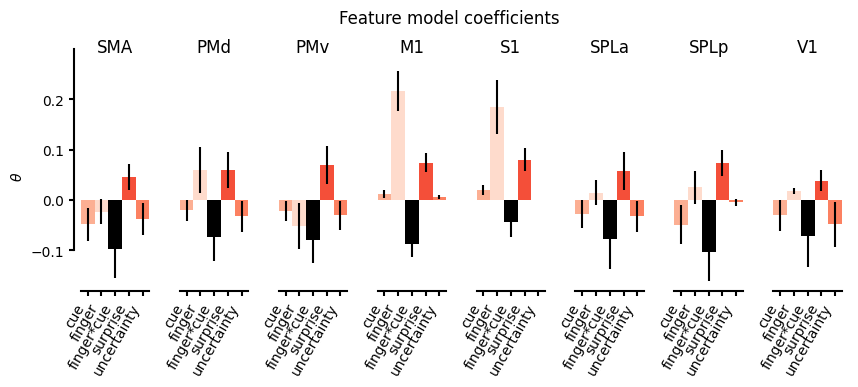

In [8]:
rois = ['SMA', 'PMd', 'PMv', 'M1', 'S1', 'SPLa', 'SPLp', 'V1']
glm = 12
Hem = 'L'
experiment = 'smp2'

M, idx = find_model(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'M.exec.glm{glm}.pkl'), 'feature')
n_param = M.n_param
features = ['finger', 'cue','uncertainty', 'surprise', 'finger*cue']

fig, axs = plt.subplots(1, len(rois), sharex=True, sharey=True, figsize=(10, 3),)

colors = sns.color_palette("Reds", n_colors=6)[:4] + [(0, 0, 0)]

for r, roi in enumerate(rois):

    f = open(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'theta_in.exec.glm{glm}.{Hem}.{roi}.pkl'), "rb")
    theta = pickle.load(f)[idx] #[:n_param]
    theta_param = theta[:n_param] / np.linalg.norm(theta[:n_param])

    theta_avg = theta_param.mean(axis=1)
    theta_err = theta_param.std(axis=1) / np.sqrt(theta_param.shape[1])

    features = np.array(features)
    idxs = np.array([0, 1, -1, 2, 3])
    order = np.argsort(features[idxs])
    axs[r].bar(features[idxs][order], theta_avg[idxs][order], width=1, yerr=theta_err[idxs][order], facecolor=np.array(colors)[idxs][order])

    axs[r].set_xticks(axs[r].get_xticks())
    axs[r].set_xticklabels(axs[r].get_xticklabels(), rotation=60, ha='right')

    axs[r].set_title(roi)

    axs[r].spines[['bottom',]].set_bounds(-.5, 4.5)
    axs[r].spines[['left',]].set_bounds(-.1, .3)
    axs[r].set_xlim(-1, 5)

    if r == 0:
        axs[r].set_ylabel(r'$\theta$')
        axs[r].spines[['top', 'right',]].set_visible(False)
        set_spines_and_ticks_width(axs[r], spine_width=1.5,spine_sides=('left', 'bottom',), tick_width=1.5,axes=('x', 'y'),which='both')
    else:
        axs[r].spines[['top', 'right','left']].set_visible(False)
        set_spines_and_ticks_width(axs[r], tick_width=0, axes='y')
        set_spines_and_ticks_width(axs[r], spine_width=1.5,spine_sides=('bottom',), tick_width=1.5,axes='x',which='both')

fig.suptitle(f'Feature model coefficients', y = 1.05)

save_figure_incremental(fig, 'feature_coeff')

plt.show()